In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ---------------------- CUSTOM PARAMETERS ----------------------
OUTPUT_DIR = "images"
#FONT_SANS_SERIF = 'Arial'
#FONT_FAMILY = 'DejaVu Sans'
FONT_SIZE_GLOBAL = 12
FONT_SIZE_TITLE = 12
FONT_SIZE_TEXT = 12
FONT_SIZE_LABEL = 12

DATASETS = ['BMMC', 'Immune', 'Lung', 'PBMC']
COLOR_SPEEDUP = '#6f3995'
LINE_WIDTH = 2.5
MARKER_SIZE = 7
PLOT_FIGSIZE = (9, 4.5)
DPI_VALUE = 300
TEXT_OFFSETS = [0.3, -0.6, 0.3, -0.6]
GRID_ALPHA = 0.2
Y_SCALE_MARGIN = 1.3

In [2]:
#plt.rcParams['font.sans-serif'] = [FONT_SANS_SERIF]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = FONT_SIZE_GLOBAL
#plt.rcParams['font.family'] = FONT_FAMILY

In [3]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
data = {
    'dataset': ['BMMC(44321)', 'BMMC(44321)',
                'PBMC(21445)', 'PBMC(21445)',
                'Immune(20783)', 'Immune(20783)',
                'Lung(7674)', 'Lung(7674)'],
    'method': ['ours', 'scgpt'] * 4,
    'memory': [5703, 17309, 6145, 17355, 5733, 17307, 5639, 17309],
    'speed': [1600.04, 197.86, 4204.90, 404.62, 1517.01, 190.67, 582.25, 72.30]
}
df = pd.DataFrame(data)

In [5]:
speed_ours = df[df.method == 'ours']['speed'].values
speed_scgpt = df[df.method == 'scgpt']['speed'].values
speedup_ratio = speed_ours / speed_scgpt

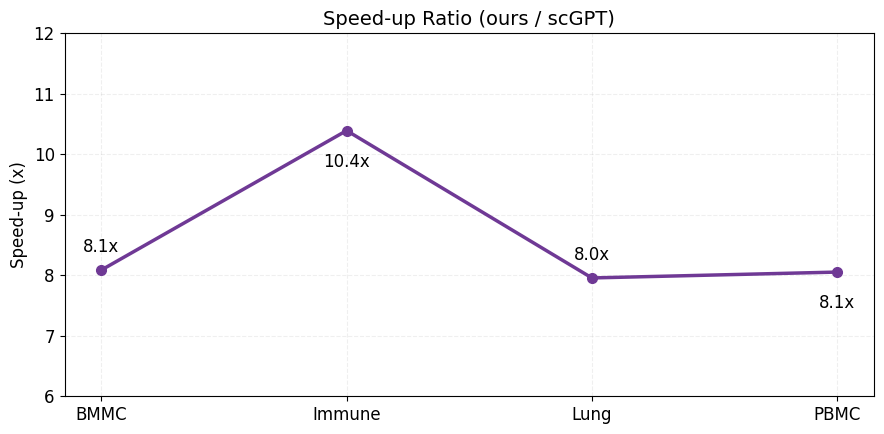

In [6]:
plt.figure(figsize=PLOT_FIGSIZE)

plt.plot(DATASETS, speedup_ratio, color=COLOR_SPEEDUP, linewidth=LINE_WIDTH, marker='o', markersize=MARKER_SIZE)

# Add text labels with staggered offsets
for i, (value, offset) in enumerate(zip(speedup_ratio, TEXT_OFFSETS)):
    plt.text(i, value + offset, f'{value:.1f}x', ha='center', fontsize=FONT_SIZE_TEXT)

plt.title('Speed-up Ratio (ours / scGPT)', fontsize=14)
plt.ylabel('Speed-up (x)', fontsize=FONT_SIZE_LABEL)
plt.grid(True, alpha=GRID_ALPHA, linestyle='--')
plt.ylim(6, 12)
plt.tight_layout()

# Save and show figure
plt.savefig(os.path.join(OUTPUT_DIR, 'speedup_ratio.png'), dpi=DPI_VALUE, bbox_inches='tight')
plt.show()
plt.close()

In [7]:
print("Speed-up ratio plot saved to:", OUTPUT_DIR)

Speed-up ratio plot saved to: images
